# 10 — Flux Cubes and MESA Integration

This notebook explains the `flux_cube.bin` binary format, how to read it directly, and how to wire the outputs into MESA's colors module.

**Key class:** `FluxCube` (from `sed_tools.flux_cube_tool`)

**File layout:** `flux_cube.bin` stores a 4-D array in `(W, M, L, T)` order on disk — wavelength outermost, Teff innermost — transposed back to `(T, L, M, W)` on load.

In [1]:
from sed_tools.flux_cube_tool import FluxCube
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np
import struct
import os

## 1. Loading a Flux Cube

`FluxCube.from_file()` reads the binary header (grid axes) and the full flux array. The array is reshaped from the on-disk `(W, M, L, T)` layout to `(T, L, M, W)` so that indexing is `flux[i_teff, i_logg, i_meta, :]`.

In [2]:
# Locate an installed flux cube
try:
    sed = SED.local('Kurucz2003all')
    cube_path = os.path.join(str(sed._model_root), 'Kurucz2003all', 'flux_cube.bin')
    cube = FluxCube.from_file(cube_path)
    print(f"Loaded: {cube_path}")
    print(f"Teff grid:  {len(cube.teff_grid)} points  ({cube.teff_grid[0]:.0f} – {cube.teff_grid[-1]:.0f} K)")
    print(f"logg grid:  {len(cube.logg_grid)} points  ({cube.logg_grid[0]:.2f} – {cube.logg_grid[-1]:.2f})")
    print(f"Meta grid:  {len(cube.meta_grid)} points  ({cube.meta_grid[0]:.2f} – {cube.meta_grid[-1]:.2f})")
    print(f"Wavelength: {len(cube.wavelengths)} points  ({cube.wavelengths[0]:.1f} – {cube.wavelengths[-1]:.1f} Å)")
    print(f"Flux shape: {cube.flux.shape}  (T, L, M, W)")
    size_gib = cube.flux.nbytes / 1024**3
    print(f"In-memory size: {size_gib:.3f} GiB")
except Exception as e:
    print(f"Could not load cube: {e}")

Loaded: /home/njm/SED_Tools/data/stellar_models/Kurucz2003all/flux_cube.bin
Teff grid:  17 points  (4000 – 8000 K)
logg grid:  5 points  (3.00 – 5.00)
Meta grid:  5 points  (-1.00 – 0.50)
Wavelength: 1199 points  (147.2 – 1600000.0 Å)
Flux shape: (17, 5, 5, 1199)  (T, L, M, W)
In-memory size: 0.004 GiB


## 2. Reading the Binary Header Directly

The binary format is simple: a 4-integer header (`nt, nl, nm, nw`) followed by the four axis arrays, then the flux data in `(W, M, L, T)` order.

In [3]:
if 'cube_path' in locals() and os.path.exists(cube_path):
    with open(cube_path, 'rb') as f:
        nt, nl, nm, nw = struct.unpack('4i', f.read(16))
        teff = np.frombuffer(f.read(8 * nt), dtype=np.float64)
        logg = np.frombuffer(f.read(8 * nl), dtype=np.float64)
        meta = np.frombuffer(f.read(8 * nm), dtype=np.float64)
        wl   = np.frombuffer(f.read(8 * nw), dtype=np.float64)

    print(f"Grid dimensions: nt={nt}, nl={nl}, nm={nm}, nw={nw}")
    print(f"Teff (first 5): {teff[:5]}")
    print(f"Total flux values: {nt * nl * nm * nw:,}")
    header_bytes = 16 + 8 * (nt + nl + nm + nw)
    data_bytes = os.path.getsize(cube_path) - header_bytes
    print(f"Header: {header_bytes} bytes, Data: {data_bytes / 1024**3:.3f} GiB")

Grid dimensions: nt=17, nl=5, nm=5, nw=1199
Teff (first 5): [4000. 4250. 4500. 4750. 5000.]
Total flux values: 509,575
Header: 9824 bytes, Data: 0.004 GiB


## 3. Extracting and Plotting a Single Node

Access a specific `(Teff, logg, [M/H])` node directly from the loaded cube.

Nearest grid node: Teff=5750 K, logg=4.50, [M/H]=0.00


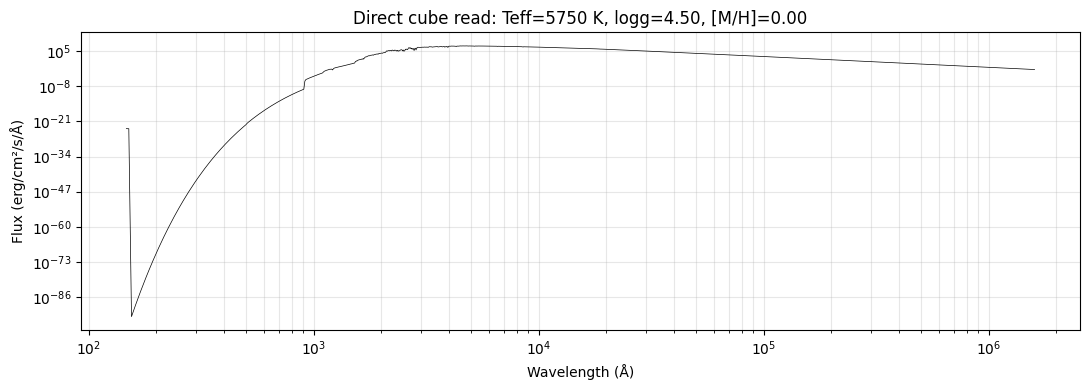

In [4]:
if 'cube' in locals():
    # Find nearest grid indices to solar parameters
    i_t = int(np.argmin(np.abs(cube.teff_grid - 5777)))
    i_l = int(np.argmin(np.abs(cube.logg_grid - 4.44)))
    i_m = int(np.argmin(np.abs(cube.meta_grid - 0.0)))

    fl_node = cube.flux[i_t, i_l, i_m, :]
    teff_node = cube.teff_grid[i_t]
    logg_node = cube.logg_grid[i_l]
    meta_node = cube.meta_grid[i_m]

    print(f"Nearest grid node: Teff={teff_node:.0f} K, logg={logg_node:.2f}, [M/H]={meta_node:.2f}")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(cube.wavelengths, fl_node, lw=0.5, color='k')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux (erg/cm²/s/Å)')
    ax.set_title(f'Direct cube read: Teff={teff_node:.0f} K, logg={logg_node:.2f}, [M/H]={meta_node:.2f}')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

## 4. Hermite Interpolation via `FluxCube`

`FluxCube.interpolate_spectrum()` performs the same cubic Hermite interpolation that `SED.__call__()` uses internally.

In [5]:
if 'cube' in locals():
    wl_interp, fl_interp = cube.interpolate_spectrum(teff=5777, logg=4.44, meta=0.0)
    print(f"Interpolated {len(fl_interp)} flux values")
    print(f"Peak flux: {fl_interp.max():.4e} erg/cm²/s/Å")

Interpolated 1199 flux values
Peak flux: 1.0048e+07 erg/cm²/s/Å


## 5. MESA Integration

Once you have a `flux_cube.bin` and `lookup_table.csv`, wire them into MESA by copying or symlinking into MESA's colors data directory.

### Directory Structure Expected by MESA
```
$MESA_DIR/colors/data/stellar_models/Kurucz2003all/
    flux_cube.bin
    lookup_table.csv
    Kurucz2003all.h5   (optional)
```

### Symlinking (recommended for development)
```bash
ln -s $(pwd)/data/stellar_models/Kurucz2003all \
      $MESA_DIR/colors/data/stellar_models/Kurucz2003all
```

### MESA Inlist
```fortran
&controls
    use_atm_for_photosphere = .true.
    atm_option = 'table'
    atm_table = 'Kurucz2003all'
/
```

### Filter Reference

MESA identifies filters by the filename stem only. For `data/filters/GAIA/GAIA/G.dat`, use `"G"` in the inlist.

In [6]:
# Print the symlink command for all locally installed models
import shutil

local_catalogs = SED.query(include_remote=False)
mesa_dir = os.environ.get('MESA_DIR', '/path/to/mesa')

print("# Symlink commands for MESA integration:")
for c in local_catalogs:
    src = os.path.join(str(SED._model_root), c.name)
    dst = os.path.join(mesa_dir, 'colors', 'data', 'stellar_models', c.name)
    print(f"ln -s {src} {dst}")

# Symlink commands for MESA integration:
ln -s /home/njm/SED_Tools/data/stellar_models/Husfeld /home/njm/MESA/mesa/colors/data/stellar_models/Husfeld
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz2003 /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz2003
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz2003all /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz2003all
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz2003all__alpha_0.4__lh_1.25__vtur_2 /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz2003all__alpha_0.4__lh_1.25__vtur_2
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz2003all__alpha_00 /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz2003all__alpha_00
ln -s /home/njm/SED_Tools/data/stellar_models/Kurucz2003all__alpha_04 /home/njm/MESA/mesa/colors/data/stellar_models/Kurucz2003all__alpha_04
ln -s /home/njm/SED_Tools/data/stellar_models/Ku